# Semantic Shard Prototype - Step 1

This notebook implements **Stage 1 only** of the prototype pipeline:
- inspect already computed semantic embeddings cache
- align embedding identities to graph metadata and deduplicated ground truth
- create conservative semantic shards (high-purity fragments)
- evaluate whether shards are tight/pure enough for later graph-based merging

Out of scope in this notebook:
- shard graph construction
- GNN training/inference
- final campaign clustering optimization


## Fast run order

Run these sections first:
1. **Setup + controls**
2. **Inspect embeddings cache structure**
3. **Identity alignment sanity check**
4. **Shard creation**
5. **Stage-1 shard quality (primary gate)**
6. **Stage-1 readiness summary**
7. **Saved artifacts**

Then optionally inspect:
- **Stage-2 merge burden (secondary)**
- **parameter sweep sanity check**


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), f"Set cwd to repo root or analysis/; got {PROJECT_ROOT}"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import graph_structure_helpers as gh
from analysis.utils import raw_gnn_notebook as rn
from analysis.utils import semantic_shard_helpers as ssh

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)


In [6]:
# -------- Controls --------
EMBEDDINGS_JSON = PROJECT_ROOT / "core" / "utils" / "embeddings" / "output" / "embeddings.json"
# Use non-pruned graph by default for this prototype.
GRAPH_PT_OVERRIDE = PROJECT_ROOT / "core" / "graph" / "output" / "incidents-lake-misp_hetero.pt"
GT_DEDUP_PATH = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth.json"

# Conservative shard settings (prefer over-splitting/high purity)
HDBSCAN_MIN_CLUSTER_SIZE = 2
HDBSCAN_MIN_SAMPLES = None
FALLBACK_COSINE_DISTANCE_THRESHOLD = 0.22  # used only if hdbscan package is unavailable
NOISE_AS_SINGLETON = True

# Optional quick sweep for sensitivity check
SHARD_PARAM_SWEEP = [
    {"min_cluster_size": 2, "min_samples": None},
    {"min_cluster_size": 3, "min_samples": None},
    {"min_cluster_size": 4, "min_samples": None},
]

ARTIFACT_OUT_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1"


## 1) Inspect `embeddings.json`

What this section does:
- loads the existing cache (no recomputation)
- validates key/value structure
- identifies which fields are semantic vectors

What to look at:
- top-level keys (`model`, `subj_dim`, `body_dim`, `by_key`)
- entry fields inside `by_key` values (`subj`, `body`, `external_id`)
- final semantic representation used for sharding: `concat(subj, body)`


In [7]:
payload, id_to_semantic, cache_summary = ssh.load_transformer_cache(EMBEDDINGS_JSON)

summary_df = pd.DataFrame([
    {
        "model": cache_summary.model,
        "subj_dim": cache_summary.subj_dim,
        "body_dim": cache_summary.body_dim,
        "semantic_concat_dim": cache_summary.subj_dim + cache_summary.body_dim,
        "n_entries_in_by_key": cache_summary.n_entries_in_by_key,
        "n_entries_with_any_vector": cache_summary.n_entries_with_any_vector,
    }
])

print("Top-level keys:", sorted(payload.keys()))
print("Sample by_key ids:", cache_summary.key_examples)
print("Entry fields detected:", cache_summary.entry_fields)

first_id = next(iter(id_to_semantic.keys()))
print(f"Sample vector dim for {first_id[:60]}...:", id_to_semantic[first_id].shape[0])

display(summary_df)


Top-level keys: ['body_dim', 'by_key', 'model', 'subj_dim']
Sample by_key ids: ['AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADiKpM1gAAAA==', 'AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADiKpM1wAAAA==', 'AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADiKpNsAAAAA==', 'AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADiKpNrwAAAA==', 'AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADiKpQVgAAAA==']
Entry fields detected: ['body', 'external_id', 'subj']
Sample vector dim for AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAAD...

,model,subj_dim,body_dim,semantic_concat_dim,n_entries_in_by_key,n_entries_with_any_vector
0,intfloat/multilingual-e5-large,1024,1024,2048,5437,5437


## 2) Identity alignment sanity check

What this section does:
- loads graph metadata identity order (`email_attrs.external_id`)
- loads deduplicated GT labels
- reports embedding ↔ graph ↔ GT overlap counts

This is the critical trust check before sharding.


In [8]:
paths = gh.resolve_graph_analysis_paths(PROJECT_ROOT)
if GRAPH_PT_OVERRIDE is not None:
    paths.graph_pt = Path(GRAPH_PT_OVERRIDE).expanduser().resolve()
    paths.meta_json = paths.graph_pt.with_suffix(".meta.json")

meta = gh.load_meta(paths.meta_json)
graph_external_ids = gh.email_external_id_list(meta)

gt_label_map, gt_rows, campaign_to_members = rn.load_ground_truth_structures(GT_DEDUP_PATH)
align = ssh.align_embedding_ids(id_to_semantic, graph_external_ids, gt_label_map)

print("graph:", paths.graph_pt)
print("meta:", paths.meta_json)
print("ground_truth_dedup:", GT_DEDUP_PATH)

align_df = pd.DataFrame([align])
display(align_df)

# Use graph-aligned embeddings for shard creation; evaluate purity on GT-covered subset.
aligned_ids_for_sharding = sorted(set(id_to_semantic.keys()) & set(graph_external_ids))
id_to_semantic_aligned = {eid: id_to_semantic[eid] for eid in aligned_ids_for_sharding}
print("n_embeddings_used_for_sharding:", len(id_to_semantic_aligned))


graph: C:\Users\aar\Desktop\GNN-Campaign-Detection\core\graph\output\incidents-lake-misp_hetero.pt
meta: C:\Users\aar\Desktop\GNN-Campaign-Detection\core\graph\output\incidents-lake-misp_hetero.meta.json
ground_truth_dedup: C:\Users\aar\Desktop\GNN-Campaign-Detection\data\groundtruth\ground_truth.json


,n_embeddings,n_graph_emails,n_gt_emails,n_emb_on_graph,n_emb_on_gt,n_emb_on_graph_and_gt
0,5437,4437,1472,4437,1472,1472


n_embeddings_used_for_sharding: 4437


## 3) Create initial semantic shards (conservative)

Method choice:
- **Primary**: HDBSCAN on L2-normalized semantic vectors (`concat(subject, body)`)
- **Fallback (if `hdbscan` package is unavailable)**: agglomerative cosine micro-clustering with conservative distance threshold
- small `min_cluster_size` to encourage over-splitting
- optional noise -> singleton shard conversion for complete assignment output

Why this method for Stage 1:
- it supports micro-clusters + noise behavior
- we can favor high-purity fragments over broad clusters


In [9]:
clustered_df = ssh.cluster_semantic_shards_hdbscan(
    id_to_semantic_aligned,
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    fallback_cosine_distance_threshold=FALLBACK_COSINE_DISTANCE_THRESHOLD,
)
assignments_df = ssh.build_shard_assignments(
    clustered_df,
    noise_as_singleton=NOISE_AS_SINGLETON,
)

print("Cluster method used:", clustered_df.attrs.get("cluster_method"))
print("Cluster label counts (raw labels; -1 = noise):")
display(clustered_df["cluster_label"].value_counts().head(15).to_frame("count"))

print("Assignments preview:")
display(assignments_df.head(10))


Cluster method used: hdbscan
Cluster label counts (raw labels; -1 = noise):


,count
cluster_label,
-1,1153
237,73
240,71
346,58
493,49
235,36
501,32
492,32
173,30


Assignments preview:


,external_id,cluster_label,is_noise,shard_id
0,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,307,False,shard_307
1,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,307,False,shard_307
2,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,310,False,shard_310
3,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
4,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,215,False,shard_215
5,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
6,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
7,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...
8,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,98,False,shard_98
9,AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEM...,-1,True,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAA...


## 4) Stage-1 shard quality (primary gate)

What this section computes (primary Stage-1 quality):
- semantic tightness of shards
- shard purity on GT-covered members
- size-weighted purity (email-mass weighted, not shard-count weighted)
- size/granularity burden (singleton-heavy vs usable micro-clusters)
- large mixed shard risk

Why this matters:
- Stage 1 should prefer **over-splitting over mixing**.
- A campaign touching many shards is acceptable at this stage.
- Large mixed shards are the main danger because Stage 2 merge should merge clean fragments, not repair mixed shards.


### Metric ledger (Stage-1 quality)

- `GT-covered shard`: shard with at least one member in deduplicated GT.
- `dominant_campaign_fraction`: dominant GT campaign share within shard (`max_campaign_count / n_members_with_gt`).
- `weighted_dominant_campaign_fraction_gt_covered`: dominant fraction weighted by GT-covered email mass in each shard.
- `frac_gt_covered_email_mass_in_shards_pure_ge_0.90`: share of GT-covered email mass that sits in shards with `dominant_campaign_fraction >= 0.90`.
- `large mixed shard`: shard with `size >= 10` and `n_gt_campaigns_touched >= 2`.
- `singleton burden`: fraction of emails assigned to size-1 shards (reported both global and GT-covered).


In [10]:
shard_summary_df, shard_overall_df = ssh.shard_quality_tables(
    assignments_df,
    id_to_semantic_aligned,
    gt_label_map,
)

# ---- Ledger / definitions ----
# GT-covered shard: shard with n_members_with_gt > 0
# dominant_campaign_fraction: (largest GT campaign count in shard) / (GT-covered members in shard)
# size-weighted purity: purity weighted by GT-covered email mass per shard
# large mixed shard: size>=10 and touches >=2 GT campaigns

id_to_campaign = {str(k): v for k, v in gt_label_map.items()}
assign_with_gt = assignments_df[assignments_df["external_id"].astype(str).isin(set(id_to_campaign.keys()))].copy()

sh_all = shard_summary_df.copy()
sh_non_single = sh_all[sh_all["size"] >= 2].copy()
sh_gt_cov = sh_all[sh_all["n_members_with_gt"] > 0].copy()
sh_gt_cov_non_single = sh_all[(sh_all["n_members_with_gt"] > 0) & (sh_all["size"] >= 2)].copy()

subset_rows = []
for name, sdf in [
    ("all_shards", sh_all),
    ("non_singleton_shards", sh_non_single),
    ("gt_covered_shards", sh_gt_cov),
    ("gt_covered_non_singleton_shards", sh_gt_cov_non_single),
]:
    if sdf.empty:
        subset_rows.append({"subset": name, "n_shards": 0})
        continue
    subset_rows.append(
        {
            "subset": name,
            "n_shards": int(len(sdf)),
            "mean_size": float(sdf["size"].mean()),
            "median_size": float(sdf["size"].median()),
            "mean_within_cos": float(sdf["within_cos_mean"].dropna().mean()),
            "frac_pure_ge_0.90": float((sdf["dominant_campaign_fraction"] >= 0.90).mean()),
            "frac_mixed_ge_2_gt_campaigns": float((sdf["n_gt_campaigns_touched"] >= 2).mean()),
        }
    )

subset_summary_df = pd.DataFrame(subset_rows)

# Size-weighted GT-covered purity
if not sh_gt_cov.empty:
    gt_mass = float(sh_gt_cov["n_members_with_gt"].sum())
    weighted_dom_frac = float(
        (sh_gt_cov["dominant_campaign_fraction"] * sh_gt_cov["n_members_with_gt"]).sum() / max(gt_mass, 1.0)
    )
    gt_mass_in_pure90 = float(sh_gt_cov.loc[sh_gt_cov["dominant_campaign_fraction"] >= 0.90, "n_members_with_gt"].sum())
    gt_mass_in_pure95 = float(sh_gt_cov.loc[sh_gt_cov["dominant_campaign_fraction"] >= 0.95, "n_members_with_gt"].sum())
else:
    gt_mass = 0.0
    weighted_dom_frac = np.nan
    gt_mass_in_pure90 = 0.0
    gt_mass_in_pure95 = 0.0

# Singleton burden
sizes_by_shard = assignments_df.groupby("shard_id").size().rename("shard_size")
assign_w_size = assignments_df.merge(sizes_by_shard, left_on="shard_id", right_index=True, how="left")
frac_emails_singleton = float((assign_w_size["shard_size"] == 1).mean())
if not assign_with_gt.empty:
    assign_with_gt = assign_with_gt.merge(sizes_by_shard, left_on="shard_id", right_index=True, how="left")
    frac_gt_emails_singleton = float((assign_with_gt["shard_size"] == 1).mean())
else:
    frac_gt_emails_singleton = np.nan

# Large mixed shard risk
large_mixed_mask = (sh_all["size"] >= 10) & (sh_all["n_gt_campaigns_touched"] >= 2)
n_large_mixed = int(large_mixed_mask.sum())
frac_large_mixed = float(large_mixed_mask.mean()) if len(sh_all) else np.nan

# Cumulative email mass by shard size buckets
size_mass = assign_w_size["shard_size"].value_counts().sort_index()
cum_size_mass_df = pd.DataFrame({
    "shard_size": size_mass.index.astype(int),
    "n_emails": size_mass.values.astype(int),
})
cum_size_mass_df["email_mass_fraction"] = cum_size_mass_df["n_emails"] / max(1, cum_size_mass_df["n_emails"].sum())
cum_size_mass_df["email_mass_cum_fraction"] = cum_size_mass_df["email_mass_fraction"].cumsum()

stage1_primary_df = pd.DataFrame([
    {"metric": "weighted_dominant_campaign_fraction_gt_covered", "value": weighted_dom_frac},
    {"metric": "frac_gt_covered_email_mass_in_shards_pure_ge_0.90", "value": gt_mass_in_pure90 / max(gt_mass, 1.0)},
    {"metric": "frac_gt_covered_email_mass_in_shards_pure_ge_0.95", "value": gt_mass_in_pure95 / max(gt_mass, 1.0)},
    {"metric": "mean_within_cos_gt_covered_non_singleton", "value": float(sh_gt_cov_non_single["within_cos_mean"].mean()) if not sh_gt_cov_non_single.empty else np.nan},
    {"metric": "frac_emails_in_singleton_shards", "value": frac_emails_singleton},
    {"metric": "frac_gt_covered_emails_in_singleton_shards", "value": frac_gt_emails_singleton},
    {"metric": "n_large_mixed_shards_size_ge_10_gt_mix_ge_2", "value": float(n_large_mixed)},
    {"metric": "frac_large_mixed_shards", "value": frac_large_mixed},
])

print("Subset quality summary (for interpretation):")
display(subset_summary_df)

print("Primary Stage-1 metrics (used for readiness):")
display(stage1_primary_df)

print("Largest shards (inspect for dangerous mixing):")
display(shard_summary_df.head(20))


Subset quality summary (for interpretation):


,subset,n_shards,mean_size,median_size,mean_within_cos,frac_pure_ge_0.90,frac_mixed_ge_2_gt_campaigns
0,all_shards,1673,2.652122,1.0,0.973859,0.205021,0.002989
1,non_singleton_shards,520,6.315385,4.0,0.973859,0.336538,0.009615
2,gt_covered_shards,348,4.772989,2.0,0.978566,0.985632,0.014368
3,gt_covered_non_singleton_shards,180,8.294444,5.0,0.978566,0.972222,0.027778


Primary Stage-1 metrics (used for readiness):


,metric,value
0,weighted_dominant_campaign_fraction_gt_covered,0.996603
1,frac_gt_covered_email_mass_in_shards_pure_ge_0.90,0.985734
2,frac_gt_covered_email_mass_in_shards_pure_ge_0.95,0.985734
3,mean_within_cos_gt_covered_non_singleton,0.978566
4,frac_emails_in_singleton_shards,0.259860
5,frac_gt_covered_emails_in_singleton_shards,0.114130
6,n_large_mixed_shards_size_ge_10_gt_mix_ge_2,0.000000
7,frac_large_mixed_shards,0.000000


Largest shards (inspect for dangerous mixing):


,shard_id,size,non_noise_member_count,n_members_with_gt,n_gt_campaigns_touched,dominant_campaign,dominant_campaign_fraction,within_cos_mean,within_cos_median
0,shard_237,73,73,0,0,NaN,NaN,1.000000,1.000000
1,shard_240,71,71,39,1,157.0,1.0,1.000000,1.000000
2,shard_346,58,58,58,1,274.0,1.0,0.944608,0.943322
3,shard_493,49,49,35,1,20.0,1.0,1.000000,1.000000
4,shard_235,36,36,36,1,157.0,1.0,1.000000,1.000000
5,shard_501,32,32,13,1,20.0,1.0,1.000000,1.000000
6,shard_492,32,32,19,1,20.0,1.0,1.000000,1.000000
7,shard_173,30,30,30,1,51.0,1.0,0.990446,0.999392
8,shard_238,27,27,0,0,NaN,NaN,1.000000,1.000000
9,shard_405,25,25,25,1,66.0,1.0,1.000000,1.000000


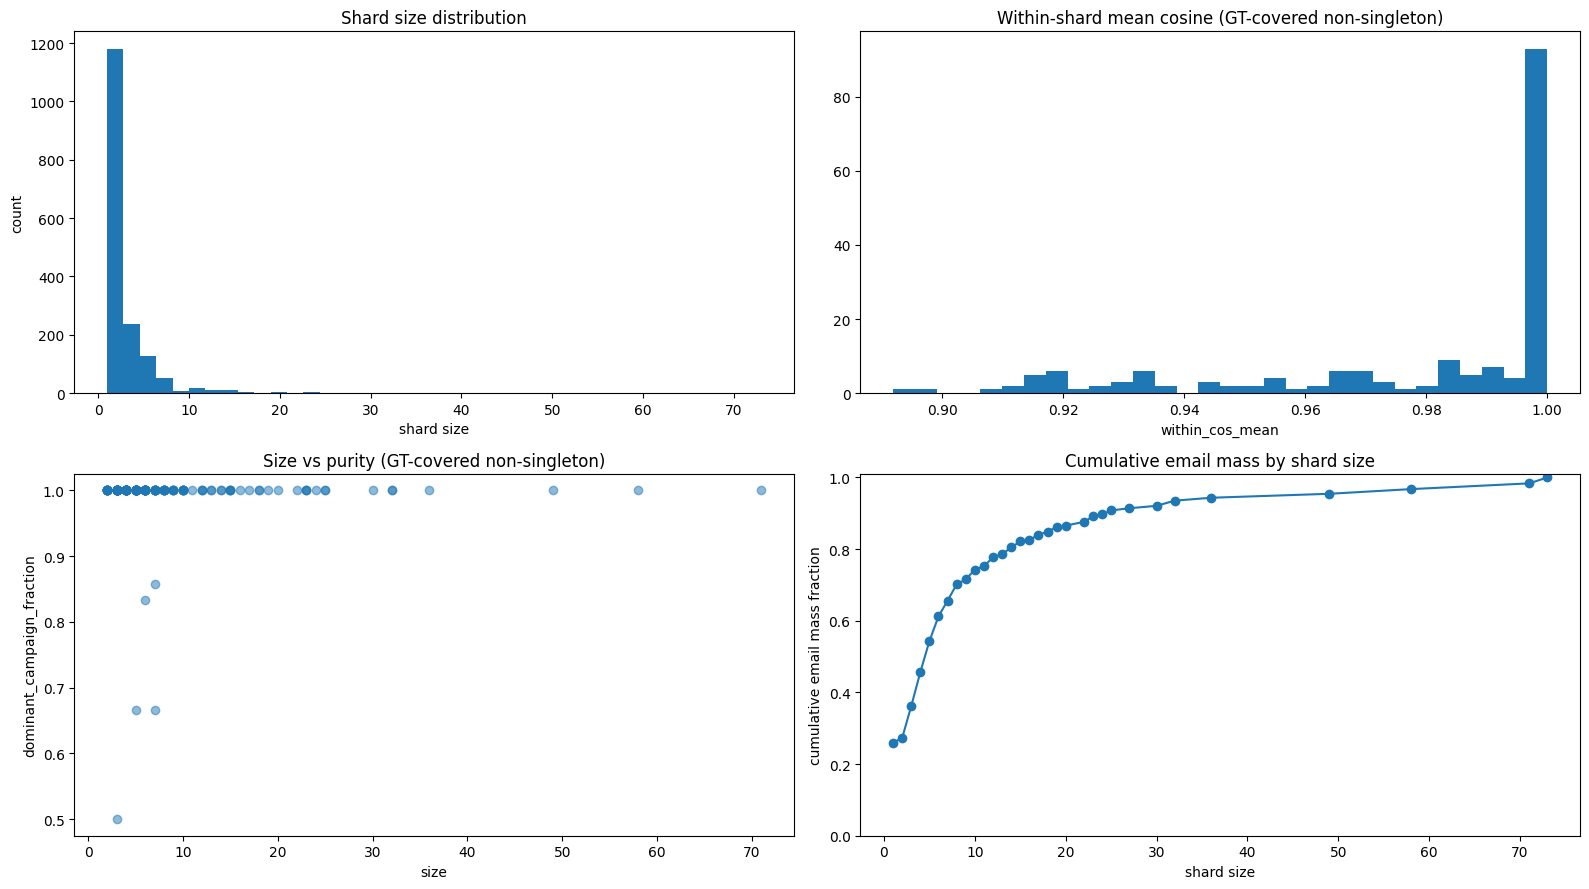

% emails in singleton shards: 26.0%
% GT-covered emails in singleton shards: 11.4%


In [11]:
# Visual diagnostics: size burden, semantic tightness, and purity structure
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0, 0].hist(shard_summary_df["size"], bins=40)
axes[0, 0].set_title("Shard size distribution")
axes[0, 0].set_xlabel("shard size")
axes[0, 0].set_ylabel("count")

axes[0, 1].hist(sh_gt_cov_non_single["within_cos_mean"].dropna(), bins=30)
axes[0, 1].set_title("Within-shard mean cosine (GT-covered non-singleton)")
axes[0, 1].set_xlabel("within_cos_mean")

axes[1, 0].scatter(
    sh_gt_cov_non_single["size"],
    sh_gt_cov_non_single["dominant_campaign_fraction"],
    alpha=0.5,
)
axes[1, 0].set_title("Size vs purity (GT-covered non-singleton)")
axes[1, 0].set_xlabel("size")
axes[1, 0].set_ylabel("dominant_campaign_fraction")

axes[1, 1].plot(cum_size_mass_df["shard_size"], cum_size_mass_df["email_mass_cum_fraction"], marker="o")
axes[1, 1].set_title("Cumulative email mass by shard size")
axes[1, 1].set_xlabel("shard size")
axes[1, 1].set_ylabel("cumulative email mass fraction")
axes[1, 1].set_ylim(0.0, 1.01)

plt.tight_layout()
plt.show()

print(f"% emails in singleton shards: {100.0 * frac_emails_singleton:.1f}%")
if pd.notna(frac_gt_emails_singleton):
    print(f"% GT-covered emails in singleton shards: {100.0 * frac_gt_emails_singleton:.1f}%")


In [12]:
# Top-N largest shard composition table
from collections import Counter

TOP_N_LARGEST = 20
largest_shards = shard_summary_df.head(TOP_N_LARGEST)["shard_id"].tolist()

comp_rows = []
id_to_campaign = {str(k): v for k, v in gt_label_map.items()}
for sid in largest_shards:
    members = assignments_df.loc[assignments_df["shard_id"] == sid, "external_id"].astype(str).tolist()
    labs = [id_to_campaign[e] for e in members if e in id_to_campaign]
    ct = Counter(labs)
    top3 = ct.most_common(3)
    comp_rows.append(
        {
            "shard_id": sid,
            "size": len(members),
            "n_members_with_gt": len(labs),
            "n_gt_campaigns_touched": len(ct),
            "top3_campaign_counts": top3,
        }
    )

largest_comp_df = pd.DataFrame(comp_rows).sort_values("size", ascending=False)
display(largest_comp_df)


,shard_id,size,n_members_with_gt,n_gt_campaigns_touched,top3_campaign_counts
0,shard_237,73,0,0,[]
1,shard_240,71,39,1,"[(157, 39)]"
2,shard_346,58,58,1,"[(274, 58)]"
3,shard_493,49,35,1,"[(20, 35)]"
4,shard_235,36,36,1,"[(157, 36)]"
5,shard_501,32,13,1,"[(20, 13)]"
6,shard_492,32,19,1,"[(20, 19)]"
7,shard_173,30,30,1,"[(51, 30)]"
8,shard_238,27,0,0,[]
9,shard_405,25,25,1,"[(66, 25)]"


## 5) Stage-1 readiness summary (fragment quality, not final campaigns)

This gate is intentionally Stage-1-specific:
- prioritize **semantic tightness**
- prioritize **size-weighted purity** on GT-covered shards
- penalize **large mixed shards**
- penalize excessive singleton burden

Secondary at this stage:
- campaign touching many shards (this mostly indicates Stage-2 merge work, not Stage-1 failure)

Metric ledger:
- `GT-covered shard`: shard with at least one email present in dedup GT.
- `dominant_campaign_fraction`: dominant GT campaign share within a shard.
- `size-weighted purity`: average dominant fraction weighted by GT-covered email count per shard.
- `large mixed shard`: shard with `size >= 10` and `n_gt_campaigns_touched >= 2`.
- `Stage-2 merge burden`: how fragmented true campaigns are across shards (informational/secondary).


In [13]:
m = {r["metric"]: float(r["value"]) for _, r in stage1_primary_df.iterrows()}

# Primary Stage-1 thresholds (heuristic, fragment-quality focused)
THRESH_WITHIN_COS = 0.90
THRESH_WEIGHTED_PURITY = 0.85
THRESH_GT_MASS_PURE90 = 0.75
THRESH_MAX_LARGE_MIXED = 10
THRESH_MAX_GT_SINGLETON_BURDEN = 0.85

checks = [
    ("semantic_tightness", m.get("mean_within_cos_gt_covered_non_singleton", np.nan) >= THRESH_WITHIN_COS),
    ("size_weighted_purity", m.get("weighted_dominant_campaign_fraction_gt_covered", np.nan) >= THRESH_WEIGHTED_PURITY),
    ("gt_email_mass_in_pure90_shards", m.get("frac_gt_covered_email_mass_in_shards_pure_ge_0.90", np.nan) >= THRESH_GT_MASS_PURE90),
    ("large_mixed_shards_control", m.get("n_large_mixed_shards_size_ge_10_gt_mix_ge_2", np.inf) <= THRESH_MAX_LARGE_MIXED),
    ("singleton_burden_control", m.get("frac_gt_covered_emails_in_singleton_shards", np.inf) <= THRESH_MAX_GT_SINGLETON_BURDEN),
]
ready = all(flag for _, flag in checks)

print("Stage-1 readiness summary (fragment-quality gate)")
for name, flag in checks:
    print(f"- {name}: {'PASS' if flag else 'FAIL'}")

print("\nKey primary metrics:")
for _, r in stage1_primary_df.iterrows():
    print(f"- {r['metric']}: {float(r['value']):.3f}")

if ready:
    print("\nInterpretation: Stage 1 looks good enough to proceed to Stage 2 merge graph design.")
else:
    print("\nInterpretation: Stage 1 likely needs tuning before Stage 2. Focus on purity/mixing/singleton burden, not campaign completeness yet.")


Stage-1 readiness summary (fragment-quality gate)
- semantic_tightness: PASS
- size_weighted_purity: PASS
- gt_email_mass_in_pure90_shards: PASS
- large_mixed_shards_control: PASS
- singleton_burden_control: PASS

Key primary metrics:
- weighted_dominant_campaign_fraction_gt_covered: 0.997
- frac_gt_covered_email_mass_in_shards_pure_ge_0.90: 0.986
- frac_gt_covered_email_mass_in_shards_pure_ge_0.95: 0.986
- mean_within_cos_gt_covered_non_singleton: 0.979
- frac_emails_in_singleton_shards: 0.260
- frac_gt_covered_emails_in_singleton_shards: 0.114
- n_large_mixed_shards_size_ge_10_gt_mix_ge_2: 0.000
- frac_large_mixed_shards: 0.000

Interpretation: Stage 1 looks good enough to proceed to Stage 2 merge graph design.


## 6) Stage-2 merge burden (secondary signal)

This section is intentionally **secondary** for Stage 1.

What it tells you:
- how much merging Stage 2 will need to do
- whether campaigns are spread across many shards

How to interpret:
- high campaign fragmentation here is acceptable if Stage-1 shards are tight/pure
- treat this as merge-work estimate, not Stage-1 failure by itself


In [ ]:
campaign_split_df = ssh.campaign_split_by_shards(assignments_df, gt_label_map)

frac_campaigns_split = float((campaign_split_df["n_shards_touched"] >= 2).mean()) if not campaign_split_df.empty else np.nan
mean_dom_shard_frac = float(campaign_split_df["dominant_shard_fraction"].mean()) if not campaign_split_df.empty else np.nan

merge_burden_df = pd.DataFrame([
    {"metric": "fraction_campaigns_touching_ge_2_shards", "value": frac_campaigns_split},
    {"metric": "mean_campaign_dominant_shard_fraction", "value": mean_dom_shard_frac},
    {"metric": "median_campaign_n_shards_touched", "value": float(campaign_split_df["n_shards_touched"].median()) if not campaign_split_df.empty else np.nan},
])

print("Stage-2 merge burden summary (secondary):")
display(merge_burden_df)

print("Most fragmented campaigns by shard split (secondary analysis):")
display(campaign_split_df.head(20))


## 7) Save shard artifacts for Stage 2 reuse

Artifacts saved:
- `semantic_shard_step1_assignments.csv` (one row per email)
- `semantic_shard_step1_shard_summary.csv` (one row per shard)
- `semantic_shard_step1_overall_summary.csv` (global metrics)
- `semantic_shard_step1_stage1_primary_metrics.csv` (Stage-1 gate metrics)
- `semantic_shard_step1_stage2_merge_burden.csv` (secondary merge-burden metrics)


In [ ]:
saved = ssh.save_shard_step1_artifacts(
    output_dir=ARTIFACT_OUT_DIR,
    assignments_df=assignments_df,
    shard_summary_df=shard_summary_df,
    overall_df=shard_overall_df,
)

stage1_csv = Path(ARTIFACT_OUT_DIR).resolve() / "semantic_shard_step1_stage1_primary_metrics.csv"
stage2_csv = Path(ARTIFACT_OUT_DIR).resolve() / "semantic_shard_step1_stage2_merge_burden.csv"
stage1_primary_df.to_csv(stage1_csv, index=False)
merge_burden_df.to_csv(stage2_csv, index=False)

for k, v in saved.items():
    print(f"{k}: {v}")
print("stage1_primary_metrics_csv:", stage1_csv)
print("stage2_merge_burden_csv:", stage2_csv)


## Optional: conservative parameter sweep (sanity check)

Use this to compare settings on Stage-1 criteria:
- weighted purity on GT-covered shards
- GT-covered email mass in pure shards
- semantic tightness (GT-covered non-singleton)
- large mixed shard count
- singleton burden on GT-covered emails


In [ ]:
sweep_rows = []
for cfg in SHARD_PARAM_SWEEP:
    cdf = ssh.cluster_semantic_shards_hdbscan(
        id_to_semantic_aligned,
        min_cluster_size=int(cfg["min_cluster_size"]),
        min_samples=cfg.get("min_samples"),
        fallback_cosine_distance_threshold=FALLBACK_COSINE_DISTANCE_THRESHOLD,
    )
    adf = ssh.build_shard_assignments(cdf, noise_as_singleton=NOISE_AS_SINGLETON)
    sdf, odf = ssh.shard_quality_tables(adf, id_to_semantic_aligned, gt_label_map)

    gt_cov = sdf[sdf["n_members_with_gt"] > 0].copy()
    gt_cov_non_single = gt_cov[gt_cov["size"] >= 2].copy()
    if not gt_cov.empty:
        gt_mass = float(gt_cov["n_members_with_gt"].sum())
        weighted_purity = float((gt_cov["dominant_campaign_fraction"] * gt_cov["n_members_with_gt"]).sum() / max(gt_mass, 1.0))
        frac_gt_mass_pure90 = float(gt_cov.loc[gt_cov["dominant_campaign_fraction"] >= 0.90, "n_members_with_gt"].sum() / max(gt_mass, 1.0))
    else:
        weighted_purity = np.nan
        frac_gt_mass_pure90 = np.nan

    sizes = adf.groupby("shard_id").size().rename("sz")
    adf_sz = adf.merge(sizes, left_on="shard_id", right_index=True, how="left")
    gt_ids = set(map(str, gt_label_map.keys()))
    adf_gt = adf_sz[adf_sz["external_id"].astype(str).isin(gt_ids)]

    sweep_rows.append(
        {
            "min_cluster_size": cfg["min_cluster_size"],
            "min_samples": cfg.get("min_samples"),
            "cluster_method": cdf.attrs.get("cluster_method"),
            "n_shards_total": int(sdf["shard_id"].nunique()),
            "mean_shard_size": float(sdf["size"].mean()),
            "weighted_purity_gt_covered": weighted_purity,
            "frac_gt_mass_in_pure90": frac_gt_mass_pure90,
            "mean_within_cos_gt_cov_non_single": float(gt_cov_non_single["within_cos_mean"].mean()) if not gt_cov_non_single.empty else np.nan,
            "n_large_mixed_shards": int(((sdf["size"] >= 10) & (sdf["n_gt_campaigns_touched"] >= 2)).sum()),
            "frac_gt_emails_in_singletons": float((adf_gt["sz"] == 1).mean()) if not adf_gt.empty else np.nan,
        }
    )

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)
